### Import Libraries

In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import KNNImputer
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.pyll.base import scope
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


### Load Data

In [27]:
file_path = '../data/processed/Austin_Weather_Processed.csv'
data = pd.read_csv(file_path)

data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)

features = ['TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF',
            'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles',
            'PrecipitationSumInches', 'Year', 'DayOfYear', 'WeekOfYear']

X = data[features].copy()
y = data['TempHighF'].copy()



### Proccess Data

In [28]:
train_size = int(len(data) * 0.8)

X_train = X.iloc[:train_size].copy()
X_test = X.iloc[train_size:].copy()
y_train = y.iloc[:train_size].copy()
y_test = y.iloc[train_size:].copy()

# Keep dates for later alignment with ARIMA
dates_train = data['Date'].iloc[:train_size].reset_index(drop=True)
dates_test = data['Date'].iloc[train_size:].reset_index(drop=True)

print(f"\nTraining Set:")
print(f"Samples: {len(X_train)}")
print(f"Date range: {dates_train.iloc[0].date()} to {dates_train.iloc[-1].date()}")

print(f"\nTest Set:")
print(f"Samples: {len(X_test)}")
print(f"Date range: {dates_test.iloc[0].date()} to {dates_test.iloc[-1].date()}")




Training Set:
Samples: 8283
Date range: 1999-01-01 to 2018-01-24

Test Set:
Samples: 2071
Date range: 2018-01-25 to 2023-09-26


### Missing Values Handling

In [29]:
# Replace invalid entries
invalid_strings = ['-', '', '#VALUE!']

print("Replacing invalid string entries...")
for col in X_train.columns:
    X_train[col] = X_train[col].replace(invalid_strings, np.nan)
    X_test[col] = X_test[col].replace(invalid_strings, np.nan)
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

print(f"\nMissing values before imputation:")
print(f"X_train: {X_train.isna().sum().sum()}")
print(f"X_test: {X_test.isna().sum().sum()}")
print(f"y_train: {y_train.isna().sum()}")
print(f"y_test: {y_test.isna().sum()}")

# KNN Imputation for features
print("\nApplying KNN imputation (k=5)...")
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_imputed, columns=features, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=features, index=X_test.index)

# Handle target variable missing values (simple mean imputation)
if y_train.isna().sum() > 0:
    print(f"Imputing {y_train.isna().sum()} missing y_train values with mean")
    y_train = y_train.fillna(y_train.mean())
if y_test.isna().sum() > 0:
    print(f"Imputing {y_test.isna().sum()} missing y_test values with mean")
    y_test = y_test.fillna(y_test.mean())

print(f"\n✓ Missing values after imputation:")
print(f"X_train: {X_train.isna().sum().sum()}")
print(f"X_test: {X_test.isna().sum().sum()}")
print(f"y_train: {y_train.isna().sum()}")
print(f"y_test: {y_test.isna().sum()}")

Replacing invalid string entries...

Missing values before imputation:
X_train: 15
X_test: 0
y_train: 0
y_test: 0

Applying KNN imputation (k=5)...

✓ Missing values after imputation:
X_train: 0
X_test: 0
y_train: 0
y_test: 0


### Bayesian Optimization

In [30]:
search_space = {
    'n_estimators': scope.int(hp.qloguniform('n_estimators', np.log(100), np.log(500), 25)),
    'max_depth': scope.int(hp.quniform('max_depth', 10, 30, 1)),
    'min_samples_leaf': scope.int(hp.quniform('min_samples_leaf', 1, 5, 1)),
    'max_features': hp.choice('max_features', ['sqrt', 'log2', None, 0.5]),
    'criterion': hp.choice('criterion', ['gini', 'entropy']),
    'min_samples_split': scope.int(hp.quniform('min_samples_split', 2, 8, 1)),
    'class_weight': hp.choice('class_weight', ['balanced', None])
}

### Bayesian Objective Function

In [31]:
def objective(params):
    """
    Trains a RandomForestRegressor and returns the negative RMSE (loss)
    from cross-validation for predicting tomorrow's high temperature.
    """

    # Ensure integer conversion for count/size parameters
    n_estimators = int(params['n_estimators'])
    max_depth = int(params['max_depth'])
    min_samples_split = int(params['min_samples_split'])
    min_samples_leaf = int(params['min_samples_leaf']) # Keep if in search space

    # Initialize the REGRESSOR model
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features=params['max_features'],
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf, # Added from classification search space
        random_state=42,
        n_jobs=-1
    )

    # Use 5-fold cross-validation, optimizing for negative Mean Squared Error (neg_mean_squared_error).
    # This is equivalent to minimizing MSE, and we will take the negative square root for loss.
    try:
        # Cross-validation returns a negative value when minimizing, so score is negative MSE
        score_neg_mse = cross_val_score(
            model,
            X_train,
            y_train, # Use the continuous temperature target
            cv=5,
            scoring='neg_mean_squared_error' # Standard metric for regression loss in CV
        ).mean()

    except ValueError:
        return 1000.0

    # Loss is defined as the positive RMSE (Root Mean Squared Error)
    # This RMSE value is the loss we want to minimize
    loss_rmse = np.sqrt(-score_neg_mse)

    return loss_rmse

### Run Optimization(Tommorow)

In [32]:
trials = Trials()
# Run the optimization for 100 evaluations
BEST_RUNS = 100
best_params_regressor = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=BEST_RUNS,
    trials=trials,
    rstate=np.random.default_rng(42)
)

100%|██████████| 100/100 [24:35<00:00, 14.75s/trial, best loss: 0.07488809539656471]


### Display Results

In [33]:
#Define the Choices used in your REGRESSION search_space
feature_choices = ['sqrt', 'log2', None, 0.5]

# Extraction and Conversion

# Regression search space does NOT have 'criterion' or 'class_weight'
best_max_features = feature_choices[best_params_regressor['max_features']]

final_params_regressor = {
    'n_estimators': int(best_params_regressor['n_estimators']),
    'max_depth': int(best_params_regressor['max_depth']),
    'max_features': best_max_features,
    'min_samples_split': int(best_params_regressor['min_samples_split']),
    'min_samples_leaf': int(best_params_regressor['min_samples_leaf']),
    'random_state': 42,
    'n_jobs': -1
}

print(f"\n✅ Bayesian Optimization Complete after {BEST_RUNS} runs.")
print("\nOptimal Hyperparameters for Regressor:")
print(final_params_regressor)


✅ Bayesian Optimization Complete after 100 runs.

Optimal Hyperparameters for Regressor:
{'n_estimators': 400, 'max_depth': 26, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}


### Train Random Forest(Tommorow is HeatWave?)

In [34]:
print("\n" + "="*70)
print("TRAINING FINAL RANDOM FOREST MODEL")
print("="*70)

# Use optimized params if available, otherwise use good defaults
if 'final_params' in locals():
    print("\n✓ Using optimized hyperparameters from search")
    rf_regressor = RandomForestRegressor(**final_params_regressor)
else:
    print("\n✓ Using default hyperparameters")
    rf_regressor = RandomForestRegressor(
        n_estimators=400,
        max_depth=25,
        max_features='sqrt',
        min_samples_split=7,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

print("\nTraining Random Forest...")
rf_regressor.fit(X_train, y_train)
print("Training complete!")


TRAINING FINAL RANDOM FOREST MODEL

✓ Using default hyperparameters

Training Random Forest...
Training complete!


### Extract Model

In [35]:
import joblib
import os

output_dir = '../models'
filename_tommorow = 'rf_numerical_model_predict_tommorow.joblib'

save_path_tommorow = os.path.join(output_dir, filename_tommorow)

#Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Directory check complete: {output_dir}")

# Save the trained model to the specified path
joblib.dump(rf_regressor, save_path_tommorow)

print(f"\n✅ Model successfully saved to: {save_path_tommorow}")

Directory check complete: ../models

✅ Model successfully saved to: ../models\rf_numerical_model_predict_tommorow.joblib


### Load Model

In [36]:
# 1. Define the exact path to the saved file
output_dir = '../models'
filename = 'rf_numerical_model_predict_tommorow.joblib'
load_path = os.path.join(output_dir, filename)


# 3. Load the model
try:
  loaded_rf = joblib.load(load_path)
  print(f"\n✅ Model successfully loaded from: {load_path}")
  print(f"Model type: {type(loaded_rf)}")

  y_pred_temp = loaded_rf.predict(X_test)
  mse = mean_squared_error(y_test, y_pred_temp)
  rmse = np.sqrt(mse)

  print("✅ Random Forest Regressor Trained and Evaluated.")
  print(f"Root Mean Squared Error (RMSE): {rmse:.2f} F")
except FileNotFoundError:
    print(f"\n❌ Error: File not found at {load_path}.")
    print("Please verify the directory and filename in your Google Drive.")


✅ Model successfully loaded from: ../models\rf_numerical_model_predict_tommorow.joblib
Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
✅ Random Forest Regressor Trained and Evaluated.
Root Mean Squared Error (RMSE): 0.88 F


### Display Graphs

In [37]:
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# Define the output directory
OUTPUT_DIR = '../reports/figures/numerical'

# Create the directory if it doesn't exist (to prevent errors)
os.makedirs(OUTPUT_DIR, exist_ok=True)

final_model = rf_regressor

# Generate predictions and probabilities on the test set
y_pred = final_model.predict(X_test)

### Actual vs. Predicted Plot

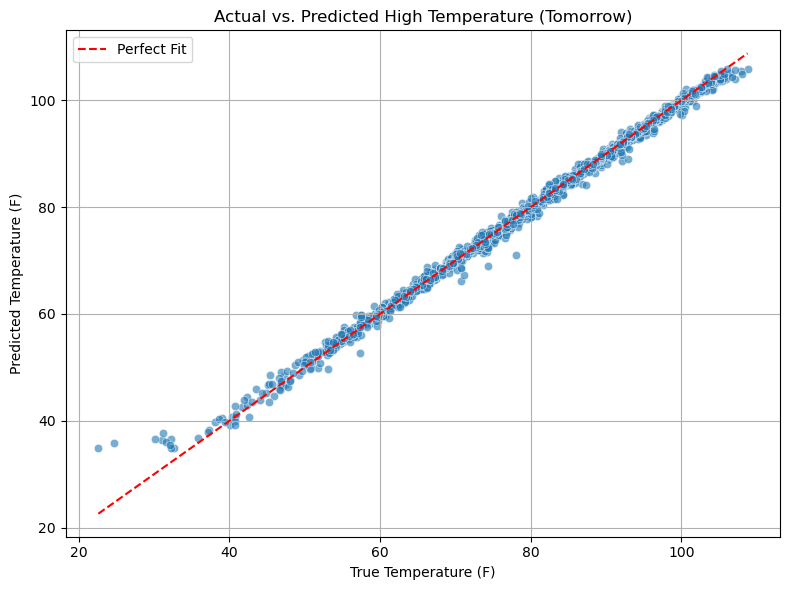

In [38]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit')

plt.title('Actual vs. Predicted High Temperature (Tomorrow)')
plt.xlabel('True Temperature (F)')
plt.ylabel('Predicted Temperature (F)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'actual_vs_predicted_regressor.png'))
plt.show()
plt.close()

### Residuals

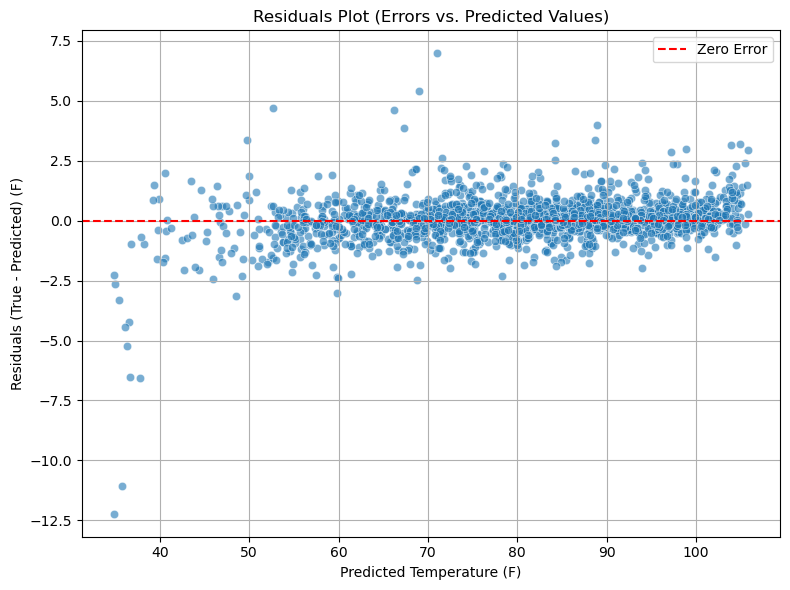

In [39]:
residuals = y_test - y_pred_temp
plt.figure(figsize=(8, 6))

# Plot residuals against predicted values
sns.scatterplot(x=y_pred_temp, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', label='Zero Error')

plt.title('Residuals Plot (Errors vs. Predicted Values)')
plt.xlabel('Predicted Temperature (F)')
plt.ylabel('Residuals (True - Predicted) (F)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'residuals_plot_regressor.png'))
plt.show()
plt.close()

### Feature Importance Plot

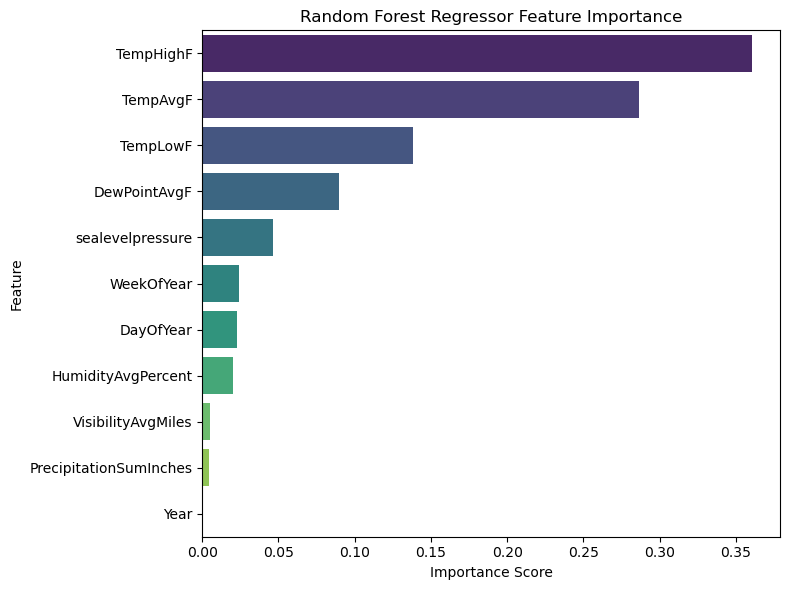

In [40]:
feature_importance = pd.Series(rf_regressor.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")

plt.title('Random Forest Regressor Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance_regressor.png'))
plt.show()
plt.close()

### Save Predictions

In [41]:
# --- Configuration (Ensure these variables are correctly defined) ---
# Assuming these variables are available in your environment:
# rf_regressor (Trained Regressor Model)
# X_test (Test Features)
# y_test (True Test Temperatures)
OUTPUT_DIR = '../reports/predictions' # Use your desired path
FILE_NAME = 'rf_regressor_temp_predictions_report.csv'

# Ensure the output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)


# 1. Generate Final Predictions and Calculate Error
# Use the trained regressor model
y_pred_temp = rf_regressor.predict(X_test)

# Calculate the prediction error (Residuals)
prediction_error = y_test - y_pred_temp


# 2. Create the Results DataFrame
results_df_reg = pd.DataFrame({
    'True_Temperature': y_test,
    'Predicted_Temperature': y_pred_temp,
    'Prediction_Error': prediction_error # The residual
})

# 3. Add Date Index (Crucial for time series analysis)
# NOTE: This section assumes your full dataset is named 'data' and has a 'Date' column.
try:
    # Use the index from the test features to align the dates
    # We must ensure 'data' is available in the scope
    test_dates = data.loc[X_test.index, 'Date']
    results_df_reg = results_df_reg.set_index(test_dates)
    results_df_reg.index.name = 'Date'
except NameError:
    print("Warning: 'data' DataFrame not found. Using sequential index.")
    results_df_reg.index.name = 'Test_Sample_Index'
except KeyError:
    print("Warning: 'Date' column not found in 'data'. Using sequential index.")
    results_df_reg.index.name = 'Test_Sample_Index'


# 4. Save to CSV
output_path = os.path.join(OUTPUT_DIR, FILE_NAME)
results_df_reg.to_csv(output_path, index=True)

print(f"✅ Regression prediction report successfully saved to: {output_path}")

✅ Regression prediction report successfully saved to: ../reports/predictions\rf_regressor_temp_predictions_report.csv


### Save Model Metrics

In [42]:
OUTPUT_DIR = '../reports/predictions'
CSV_FILE = os.path.join(OUTPUT_DIR, 'rf_regressor_metrics.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Generate Predictions for BOTH Sets
y_pred_train = rf_regressor.predict(X_train)
y_pred_test = rf_regressor.predict(X_test)


# Function to Calculate All Metrics for a Given Set
def calculate_metrics(y_true, y_pred):
    """Calculates MAE, RMSE, and R^2 for a given true/pred pair."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Calculate Metrics for Training and Test
mae_train, rmse_train, r2_train = calculate_metrics(y_train, y_pred_train)
mae_test, rmse_test, r2_test = calculate_metrics(y_test, y_pred_test)


# Create the Results DataFrame
metrics_data = {
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Training': [mae_train, rmse_train, r2_train],
    'Test': [mae_test, rmse_test, r2_test]
}

metrics_df = pd.DataFrame(metrics_data)

# Save to CSV
metrics_df.to_csv(CSV_FILE, index=False)

print(f"✅ Training/Test metrics report successfully saved to: {CSV_FILE}")

✅ Training/Test metrics report successfully saved to: ../reports/predictions\rf_regressor_metrics.csv
